<a href="https://colab.research.google.com/github/dallinmoore/DATA_5630_Deep_Forecasting/blob/main/Homework(my-branch-only)/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 5630 - HW6
Dallin Moore

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/US_macro_Quarterly.csv", index_col=0)
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [3]:
df.index = pd.to_datetime(df.index)
df.index

DatetimeIndex(['1959-03-31', '1959-06-30', '1959-09-30', '1959-12-31',
               '1960-03-31', '1960-06-30', '1960-09-30', '1960-12-31',
               '1961-03-31', '1961-06-30',
               ...
               '2007-06-30', '2007-09-30', '2007-12-31', '2008-03-31',
               '2008-06-30', '2008-09-30', '2008-12-31', '2009-03-31',
               '2009-06-30', '2009-09-30'],
              dtype='datetime64[ns]', length=203, freq=None)

In [4]:
df = df.loc[:, ['cpi']]
df.head()

,cpi
1959-03-31,28.98
1959-06-30,29.15
1959-09-30,29.35
1959-12-31,29.37
1960-03-31,29.54


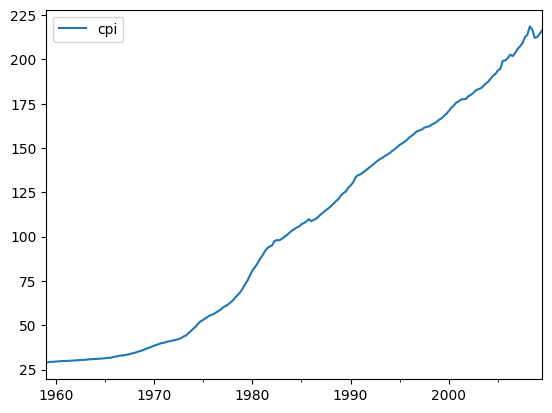

In [5]:
df.plot()
plt.show()

## 4.
Q: There is a clear upward trend in the cpi data. Using Deep Neural Networks (DNN), do you think we need to de-trend the cpi data and make it stationary? what are the advantages and disadvantages?

A: No, strictly speaking deep neural networks are able to learn the trend and even the season if present. However, DNNs can struggle with long-term dependencies in non-stationary data and removing trends can help the model focus on learning meaningful patterns rather than just fitting the overall trend. On the other hand, removing the trend might result in a loss of valuable information, leading to poor quality forecasts. Plus, the model's outputs need to be re-transformed after predicting.



In [6]:
test_period = 24
train_period = len(df) - test_period

print(f"Train period: {train_period}")
print(f"Test period: {test_period}")

Train period: 179
Test period: 24


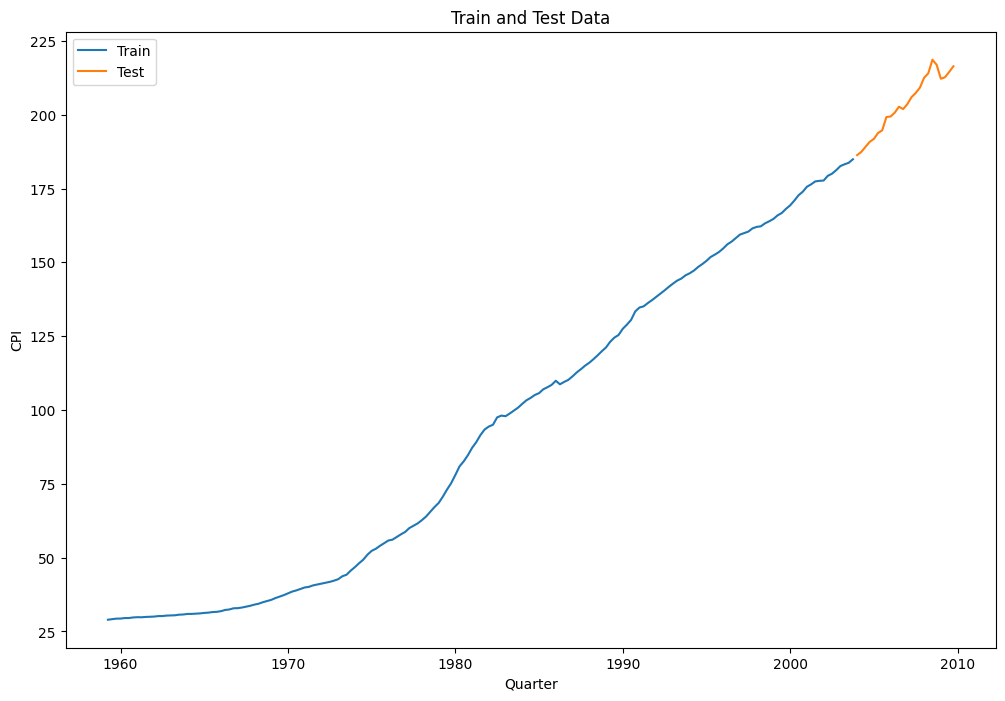

In [7]:
train = df.iloc[:train_period]
test = df.iloc[train_period:]

# plotting the train and test data with different colors
plt.figure(figsize=(12, 8))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.title('Train and Test Data')
plt.xlabel('Quarter')
plt.ylabel('CPI')
plt.legend()
plt.show()

In [8]:
# A Boolean series indicating which rows of the DataFrame data belong to each set (train, test)
train_indicator = (df.index <= train.index[-1])
test_indicator =  (df.index > train.index[-1])

# creating feature space X and target variable y for the training and test datasets
series = df['cpi'].dropna().to_numpy()

In [9]:
Tx = 8 # Number of lags! using the past Tx observations to forecast the next one.
Ty = 1 #  Forecasting Ty outputs at once
X = np.array([series[t:t+Tx] for t in range(len(series) - Tx-Ty+1)])
Y = np.array([series[t+Tx: t+Tx+Ty] for t in range(len(series) - Tx-Ty+1)])
N = len(X)

print("X:", X.shape, "Y:", Y.shape, "N:", N)

X: (195, 8) Y: (195, 1) N: 195


In [10]:
# 6
Xtrain, Ytrain = X[:-test_period], Y[:-test_period]
Xtest, Ytest = X[-test_period:], Y[-test_period:]
Xtrain.shape, Ytrain.shape, Xtest.shape, Ytest.shape

((171, 8), (171, 1), (24, 8), (24, 1))

In [11]:
# 7

def build_model(Tx, Ty):
    i = Input(shape=(Tx,))
    x = Dense(32, activation='relu')(i)
    x = Dense(16, activation='relu')(x)
    output = Dense(Ty , activation = 'linear')(x)
    model = Model(i, output)
    model.compile(loss='mse', optimizer='adam')
    return model



## 7

Q: Why it is NOT recommended to use less than 8 nodes in the first hidden layer?

A: The there are 8 parameters in the input so anything else would bottleneck the model and not allow it to learn all 8 inputs properly.

---

Q: Why can you use either "linear" or "ReLU" in this example?

A: For the output activation function, 'linear' or 'ReLU' could be used because the output data is not constriained by the values in the input. The output should continue to increase in the future.


In [12]:
model_DNN = build_model(Tx, Ty)
model_DNN.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
8*32+32

288

In [14]:
32*16+16

528

In [15]:
16*1+1

17

In [16]:
288+528+17

833

## 8

Q: How many trainable parameters does your model have?

A: Overall, the model has 833 trainable parameter. 288 in the first output layer because there is a connection between every input node and dense layer node (8*32) and each output neuron has its own set of weights and a bias term (256+32).

In [17]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
model_DNN.fit(Xtrain, Ytrain, epochs=100, batch_size=16, validation_data=(Xtest, Ytest))


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 2988.5369 - val_loss: 327.6825
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 76.3500 - val_loss: 987.9048
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 207.0596 - val_loss: 64.3991
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 15.2270 - val_loss: 78.9403
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 27.4601 - val_loss: 11.9395
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.0288 - val_loss: 31.7140
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.4280 - val_loss: 9.2996
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.4830 - val_loss: 11.2271
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.6506 - val_loss: 14.0458
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.8117 - val_loss: 11.4936
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5292 - val_loss: 11.7863
Epoch 12/100
11/11 ━━━━━━━━━━━━━

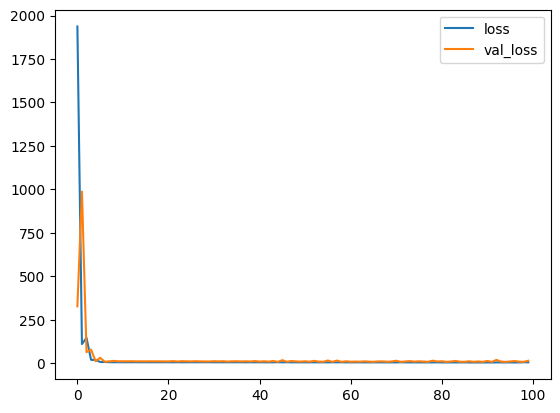

In [18]:
loss_df = pd.DataFrame(model_DNN.history.history)
loss_df[['loss', 'val_loss']].plot(legend=True)
plt.show()

## 10

Q: At what epoch number did your model stopped training and why?

A: Early stopping was set to monitor validation loss with patience set to 10, meaning that if after 10 epochs in a row the validation loss didn't get better the model would stop training. At epoch 90, the validation loss was 12.4, but it increased in the very next epoch. The model stopped at the max of 100 epochs because it continued to improve, or at least have varying validation loss.

In [19]:
train_indicator[:Tx] = False
DNN_1step_train_forecast = model_DNN.predict(Xtrain)
DNN_1step_test_forecast = model_DNN.predict(Xtest)
df.loc[train_indicator, '1step_train_forecast'] = DNN_1step_train_forecast
df.loc[test_indicator, '1step_test_forecast'] = DNN_1step_test_forecast
df.tail(32)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


,cpi,1step_train_forecast,1step_test_forecast
2001-12-31,177.700,182.185501,NaN
2002-03-31,179.300,182.949982,NaN
2002-06-30,180.000,184.011246,NaN
2002-09-30,181.200,184.797592,NaN
2002-12-31,182.600,185.676071,NaN
2003-03-31,183.200,186.490860,NaN
2003-06-30,183.700,187.252426,NaN
2003-09-30,184.900,188.637985,NaN
2003-12-31,186.300,NaN,189.246460
2004-03-31,187.400,NaN,190.383438


In [20]:
multistep_predictions = []

# first test input
input_X = Xtest[0]

# Start a loop that will continue until we have the desired number of future forecasts (test_period).
while len(multistep_predictions) < test_period:
  prediction = model_DNN.predict(input_X.reshape(1, -1))[0]

  # update the predictions list
  multistep_predictions.append(prediction)

  # update the new input
  # The input_X array, which serves as input for the next prediction, is updated. The np.roll(input_X, -1) shifts all elements of input_X one position to the left.
  # The last element of last_x, which is now freed up, is filled with the last prediction p.
  input_X = np.roll(input_X, -1)
  input_X[-1] = prediction

df.loc[test_indicator, 'multistep_test_forecast'] = multistep_predictions
df.tail(32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


<ipython-input-20-06b092f01dec>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_X[-1] = prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


,cpi,1step_train_forecast,1step_test_forecast,multistep_test_forecast
2001-12-31,177.700,182.185501,NaN,NaN
2002-03-31,179.300,182.949982,NaN,NaN
2002-06-30,180.000,184.011246,NaN,NaN
2002-09-30,181.200,184.797592,NaN,NaN
2002-12-31,182.600,185.676071,NaN,NaN
2003-03-31,183.200,186.490860,NaN,NaN
2003-06-30,183.700,187.252426,NaN,NaN
2003-09-30,184.900,188.637985,NaN,NaN
2003-12-31,186.300,NaN,189.246460,189.246445
2004-03-31,187.400,NaN,190.383438,190.297775


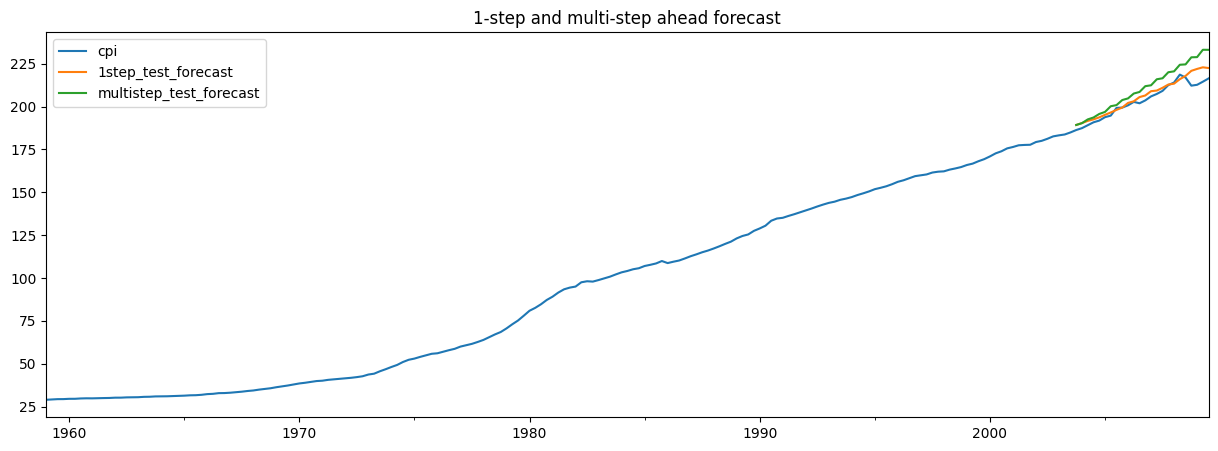

In [21]:
df[['cpi', '1step_test_forecast', 'multistep_test_forecast']].plot(figsize=(15, 5))
plt.title('1-step and multi-step ahead forecast')
plt.show()


In [22]:
Tx = 8
Ty = test_period # number of outputs forecasted at once

# Create input-output pairs
X = np.array([series[t:t+Tx] for t in range(len(series) - Tx - Ty+1)])
Y = np.array([series[t+Tx:t+Tx+Ty] for t in range(len(series) - Tx - Ty+1)])
N = len(X)

print("X:", X.shape, "Y:", Y.shape, "N:", N)


X: (172, 8) Y: (172, 24) N: 172


In [23]:
Xtrain_mo, Ytrain_mo = X[:-1], Y[:-1]
Xtest_mo, Ytest_mo = X[-1:], Y[-1:]
Xtrain_mo.shape, Ytrain_mo.shape, Xtest_mo.shape, Ytest_mo.shape

((171, 8), (171, 24), (1, 8), (1, 24))

In [24]:
model_DNN_mo = build_model(Tx, Ty)
model_DNN_mo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224 (4.78 KB)

 Trainable params: 1,224 (4.78 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
model_DNN_mo.fit(Xtrain_mo, Ytrain_mo, epochs=200, batch_size=16, validation_data=(Xtest_mo, Ytest_mo), callbacks=[early_stopping])

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 13810.4961 - val_loss: 38468.8477
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12736.2090 - val_loss: 36323.8203
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12219.8457 - val_loss: 33809.7852
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11868.1982 - val_loss: 30724.8340
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10532.6309 - val_loss: 27266.2812
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8626.1162 - val_loss: 23770.8848
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7832.8452 - val_loss: 20481.3418
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6996.3203 - val_loss: 17354.8066
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5879.9902 - val_loss: 14414.1172
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4689.0039 - val_loss: 11664.3320
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4105.219

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


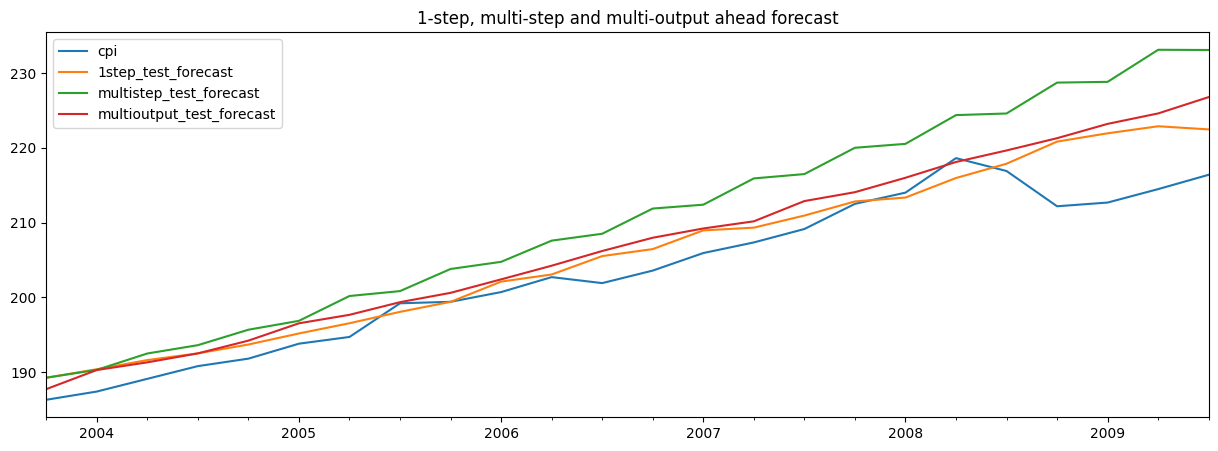

In [26]:
DNN_mo_train_forecast = model_DNN_mo.predict(Xtrain_mo)
DNN_mo_test_forecast = model_DNN_mo.predict(Xtest_mo)
df.loc[test_indicator, 'multioutput_test_forecast'] = DNN_mo_test_forecast[0]
df[['cpi', '1step_test_forecast', 'multistep_test_forecast', 'multioutput_test_forecast' ]].tail(24).plot(figsize=(15, 5))
plt.title('1-step, multi-step and multi-output ahead forecast')
plt.show()

In [27]:
cpi_test = df.loc[test_indicator, 'cpi']
mape1 = mean_absolute_percentage_error(cpi_test, df.loc[test_indicator, '1step_test_forecast'])
mape2 = mean_absolute_percentage_error(cpi_test, df.loc[test_indicator, 'multistep_test_forecast'])
mape3 = mean_absolute_percentage_error(cpi_test, df.loc[test_indicator, 'multioutput_test_forecast'])
print("1step_test MAPE:", mape1)
print("multi-step MAPE:", mape2)
print("multi-output MAPE:", mape3)

1step_test MAPE: 0.013847756271335382
multi-step MAPE: 0.034539807166057986
multi-output MAPE: 0.017401430619047375
